# Model Experimentation — Day 2

This experiment focuses on `target_aqi_day2`.

## Approach

1. Load the full 49-feature modeling dataset and create chronological train/validation/test splits.
2. Combine the training and validation sets into a single pool for feature selection, hyperparameter tuning, and model comparison.
3. Keep the test set completely untouched until the final evaluation.
4. Experiment with **Random Forest**, applying RFECV with `TimeSeriesSplit(5)` and tuning the selected feature set using time-series cross-validation.
5. Experiment with **Ridge Regression**, applying the existing preprocessing, RFECV, and alpha tuning using `TimeSeriesSplit(5)`.
6. Experiment with **XGBoost**, applying RFECV and hyperparameter tuning using `TimeSeriesSplit(5)`.
7. Experiment with **LightGBM**, applying RFECV and hyperparameter tuning using `TimeSeriesSplit(5)`.
8. Experiment with **MLP** using the feature subset selected by Ridge RFECV, manually evaluating architecture variants across the same five time-series folds.
9. Compare the five model types using their CV-averaged R², RMSE, and MAE.
10. Select the best-performing configuration for Day 1 based only on cross-validation results.
11. Retrain the winning configuration on the full train+validation pool.
12. Evaluate the final Day 1 model once on the untouched test set.
13. Record the final test metrics and selected configuration for the Day 1 experiment.

In [1]:
import random

from src.common.constants import ALL_LOG_TRANSFORM_FEATURES, ALL_TRAINING_FEATURES, TARGET_COLUMNS
from src.modeling.data_utils import load_modeling_data, split_modeling_data, preprocess_data

import shap
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.linear_model import Ridge
from sklearn.feature_selection import RFECV
from sklearn.model_selection import GridSearchCV
from tensorflow.keras import layers, regularizers
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.metrics import r2_score, root_mean_squared_error, mean_absolute_error

In [2]:
df = load_modeling_data()

train_df, val_df, test_df = split_modeling_data(df)

target_label = ["target_aqi_day2"]

In [3]:
train_df_preprocess, val_df_preprocess, test_df_preprocess = preprocess_data(train_df, val_df, test_df, log_features=ALL_LOG_TRANSFORM_FEATURES, scale_features=ALL_TRAINING_FEATURES)

In [4]:
train_val_df = pd.concat(
    [train_df, val_df],
    axis=0,
).sort_values("ts").reset_index(drop=True)

train_val_df_preprocess = pd.concat(
    [train_df_preprocess, val_df_preprocess],
    axis=0,
).sort_values("ts").reset_index(drop=True)

X = train_val_df.drop(
    columns=["ts"] + TARGET_COLUMNS,
)

X_preprocess = train_val_df_preprocess.drop(
    columns=["ts"] + TARGET_COLUMNS,
)

y = train_val_df_preprocess[target_label].to_numpy().ravel()

X_test = test_df.drop(
    columns=["ts"] + TARGET_COLUMNS,
)

X_test_preprocess = test_df_preprocess.drop(
    columns=["ts"] + TARGET_COLUMNS,
)

y_test = test_df[target_label].to_numpy().ravel()

tscv = TimeSeriesSplit(n_splits=5)

In [5]:
def pred_test(model, model_type, tuned_on, X_test_req = X_test_preprocess, features = None):
    if features is None:
        y_test_pred = model.predict(X_test_req).ravel()
    else:
        y_test_pred = model.predict(X_test_req[features]).ravel()


    r2 = r2_score(y_test, y_test_pred)
    rmse = root_mean_squared_error(y_test, y_test_pred)
    mae = mean_absolute_error(y_test, y_test_pred)

    print("=" * 40)
    print(f"       {model_type} (Tuned on {tuned_on} Feature Set) — Day 1")
    print("=" * 40)
    print(f"R²   : {r2:.4f}")
    print(f"RMSE : {rmse:.4f}")
    print(f"MAE  : {mae:.4f}")
    print("=" * 40)

def perform_rfecv(model, X_req = X_preprocess):
    rfecv = RFECV(
        estimator=model,
        step=1,
        scoring="r2",
        cv=tscv,
        n_jobs=-1,
        verbose=1,
    )

    rfecv.fit(X_req, y)

    selected_features = X_req.columns[rfecv.support_]

    X_selected = X_req[selected_features]

    print(f"Selected features: {len(selected_features)} / {X_req.shape[1]}")
    print("\nSelected feature set:")
    print(list(selected_features))

    return selected_features, X_selected

def get_random_search(model):
    return RandomizedSearchCV(
        estimator=model,
        param_distributions=param_distributions,
        n_iter=30,
        scoring="r2",
        cv=tscv,
        random_state=42,
        n_jobs=-1,
        verbose=1,
    )

def tune_hyperparameter(X_df, model_func, search_func):
    model = model_func()

    search = search_func(model)

    search.fit(X_df, y)

    best_model = search.best_estimator_

    print("Best parameters:")
    print(search.best_params_)

    print("\nBest CV R²:")
    print(search.best_score_)

    return best_model

## Experiment 1 — Random Forest

This experiment focuses exclusively on `target_aqi_day2` using Random Forest.

The goal is to determine the best-performing Random Forest configuration for Day 1 by:

1. Using all engineered features except `ts`.
2. Applying RFECV with `TimeSeriesSplit(5)` for feature selection.
3. Tuning the Random Forest hyperparameters using `TimeSeriesSplit(5)`.
4. Retraining the finalized Random Forest on the full train+validation pool.
5. Evaluating the final model once on the untouched test set.

In [6]:
param_distributions = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [None, 5, 10, 15, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4, 8],
    "max_features": ["sqrt", "log2", 0.5, 0.75, 1.0],
}

def get_random_forest_model():
    return RandomForestRegressor(
        random_state=42,
        n_jobs=-1,
    )

def tune_random_forest_hyperparameter(X_df):
    return tune_hyperparameter(X_df, get_random_forest_model, get_random_search)

In [7]:
best_model_random_forest = tune_random_forest_hyperparameter(X)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best parameters:
{'n_estimators': 200, 'min_samples_split': 10, 'min_samples_leaf': 8, 'max_features': 0.5, 'max_depth': None}

Best CV R²:
0.46664191875870886


The tuned Random Forest achieved a cross-validation R² of **0.467** across the five time-series folds. The best configuration uses **200 trees**, unlimited `max_depth`, `min_samples_split=10`, `min_samples_leaf=8`, and `max_features=0.5`.

In [8]:
pred_test(best_model_random_forest, "Random Forest", "Full", X_test_req=X_test)

       Random Forest (Tuned on Full Feature Set) — Day 1
R²   : 0.6225
RMSE : 29.4452
MAE  : 22.0099


The tuned Random Forest achieved a test R² of **0.6225**, with an RMSE of **29.4452** and MAE of **22.0099** on the untouched test set. The model shows substantially weaker Day 2 prediction performance compared with its Day 1 results.

In [9]:
# Feature selection
random_forest = get_random_forest_model()

random_forest_rfecv_features, X_selected = perform_rfecv(random_forest, X_req=X)

Fitting estimator with 49 features.
Fitting estimator with 48 features.
Fitting estimator with 47 features.
Fitting estimator with 46 features.
Selected features: 45 / 49

Selected feature set:
['aqi_today', 'aqi_lag_1', 'aqi_lag_3', 'aqi_roll_mean_7', 'aqi_roll_std_3', 'aqi_roll_std_7', 'aqi_change_rate', 'pm25_today', 'pm10_today', 'o3_today', 'co_today', 'no2_today', 'so2_today', 'temp_today', 'pressure_today', 'humidity_today', 'wind_spd_today', 'dew_pt_today', 'pm25_lag_1', 'pm10_lag_1', 'o3_lag_1', 'pm25_lag_2', 'pm10_lag_2', 'o3_lag_2', 'pm25_lag_3', 'pm10_lag_3', 'o3_lag_3', 'temp_lag_1', 'pressure_lag_1', 'humidity_lag_1', 'wind_spd_lag_1', 'dew_pt_lag_1', 'pm25_roll_mean_3', 'pm25_roll_mean_7', 'pm10_roll_mean_3', 'pm10_roll_mean_7', 'o3_roll_mean_3', 'o3_roll_mean_7', 'pm25_roll_std_3', 'pm25_roll_std_7', 'pm10_roll_std_3', 'pm10_roll_std_7', 'o3_roll_std_3', 'o3_roll_std_7', 'month']


RFECV reduced the Random Forest feature set from **49 to 45 features**, indicating that most of the engineered features were retained for Day 2 prediction.

In [10]:
best_model_random_forest_rfecv = tune_random_forest_hyperparameter(X_selected)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best parameters:
{'n_estimators': 100, 'min_samples_split': 10, 'min_samples_leaf': 8, 'max_features': 0.5, 'max_depth': 10}

Best CV R²:
0.4741311952297245


The tuned Random Forest achieved a cross-validation R² of **0.474** across the five time-series folds. The best configuration uses **100 trees**, `max_depth=10`, `min_samples_split=10`, `min_samples_leaf=8`, and `max_features=0.5`.

In [11]:
pred_test(best_model_random_forest, "Random Forest", "Full", X_test_req=X_test)
pred_test(best_model_random_forest_rfecv, "Random Forest", "RFCEV", X_test_req=X_test, features=random_forest_rfecv_features)

       Random Forest (Tuned on Full Feature Set) — Day 1
R²   : 0.6225
RMSE : 29.4452
MAE  : 22.0099
       Random Forest (Tuned on RFCEV Feature Set) — Day 1
R²   : 0.6272
RMSE : 29.2609
MAE  : 22.0371


The RFECV-based Random Forest slightly outperformed the full-feature model on the untouched test set. R² improved from **0.6225 to 0.6272**, while RMSE decreased from **29.4452 to 29.2609**. MAE increased slightly from **22.0099 to 22.0371**.

## Experiment 2 — Ridge Regression

This experiment focuses exclusively on `target_aqi_day2` using Ridge Regression.

The goal is to determine the best-performing Ridge Regression configuration for Day 1 by:

1. Using all engineered features except `ts`.
2. Applying the existing preprocessing approach with `log1p` transformations where applicable and `RobustScaler`.
3. Applying RFECV with `TimeSeriesSplit(5)` for feature selection.
4. Tuning the Ridge `alpha` hyperparameter using `TimeSeriesSplit(5)`.
5. Recording the mean cross-validation R², RMSE, and MAE across the five time-series folds.
6. Retraining the finalized Ridge model on the full train+validation pool.
7. Evaluating the final model once on the untouched test set.

In [12]:
param_distributions = {
    "alpha": [
        0.001,
        0.01,
        0.1,
        1.0,
        10.0,
        100.0,
        1000.0,
    ],
}

def get_ridge_model():
    return Ridge(
        random_state=42,
    )

def get_grid_search(ridge_model):
    return GridSearchCV(
        estimator=ridge_model,
        param_grid=param_distributions,
        scoring="r2",
        cv=tscv,
        n_jobs=-1,
        verbose=1,
    )

def tune_ridge_hyperparameter(X_df):
    return tune_hyperparameter(X_df, get_ridge_model, get_grid_search)

In [13]:
best_model_ridge_regression = tune_ridge_hyperparameter(X_preprocess)

Fitting 5 folds for each of 7 candidates, totalling 35 fits
Best parameters:
{'alpha': 100.0}

Best CV R²:
0.47968012521723313


Using the full feature set, Ridge Regression achieved a cross-validation R² of **0.480** across the five time-series folds. The best-performing regularization strength was **alpha = 100.0**.

In [14]:
pred_test(best_model_ridge_regression, "Ridge Regression", "Full")

       Ridge Regression (Tuned on Full Feature Set) — Day 1
R²   : 0.6015
RMSE : 30.2552
MAE  : 22.4052


The tuned Ridge Regression achieved a test R² of **0.6015**, with an RMSE of **30.2552** and MAE of **22.4052** on the untouched test set. The model shows substantially weaker Day 2 prediction performance compared with its Day 1 results.

In [15]:
ridge_regression = get_ridge_model()

ridge_regression_rfecv_features, X_selected = perform_rfecv(ridge_regression)

Fitting estimator with 49 features.
Fitting estimator with 48 features.
Fitting estimator with 47 features.
Fitting estimator with 46 features.
Fitting estimator with 45 features.
Fitting estimator with 44 features.
Fitting estimator with 43 features.
Fitting estimator with 42 features.
Fitting estimator with 41 features.
Fitting estimator with 40 features.
Fitting estimator with 39 features.
Fitting estimator with 38 features.
Fitting estimator with 37 features.
Fitting estimator with 36 features.
Fitting estimator with 35 features.
Fitting estimator with 34 features.
Fitting estimator with 33 features.
Fitting estimator with 32 features.
Fitting estimator with 31 features.
Fitting estimator with 30 features.
Fitting estimator with 29 features.
Fitting estimator with 28 features.
Fitting estimator with 27 features.
Fitting estimator with 26 features.
Fitting estimator with 25 features.
Fitting estimator with 24 features.
Fitting estimator with 23 features.
Fitting estimator with 22 fe

RFECV reduced the Ridge Regression feature set from **49 to 3 features**, retaining `aqi_roll_mean_3`, `pm25_today`, and `pm25_roll_mean_7` for Day 2 prediction.

In [16]:
best_model_ridge_regression_rfecv = tune_ridge_hyperparameter(X_selected)

Fitting 5 folds for each of 7 candidates, totalling 35 fits
Best parameters:
{'alpha': 0.001}

Best CV R²:
0.5075489763958917


After RFECV, the tuned Ridge Regression achieved a cross-validation R² of **0.508** using **alpha = 0.001** across the reduced **3-feature set**.

In [17]:
pred_test(best_model_ridge_regression, "Ridge Regression", "Full")
pred_test(best_model_ridge_regression_rfecv, "Ridge Regression", "RFCEV", features=ridge_regression_rfecv_features)

       Ridge Regression (Tuned on Full Feature Set) — Day 1
R²   : 0.6015
RMSE : 30.2552
MAE  : 22.4052
       Ridge Regression (Tuned on RFCEV Feature Set) — Day 1
R²   : 0.6071
RMSE : 30.0412
MAE  : 22.7591


RFECV slightly improved the Ridge Regression performance on the untouched test set. R² increased from **0.6015 to 0.6071**, while RMSE decreased from **30.2552 to 30.0412**. However, MAE increased from **22.4052 to 22.7591**.

In [18]:
pred_test(best_model_ridge_regression_rfecv, "Ridge Regression", "RFCEV", features=ridge_regression_rfecv_features)
pred_test(best_model_random_forest_rfecv, "Random Forest", "RFCEV", X_test_req=X_test, features=random_forest_rfecv_features)

       Ridge Regression (Tuned on RFCEV Feature Set) — Day 1
R²   : 0.6071
RMSE : 30.0412
MAE  : 22.7591
       Random Forest (Tuned on RFCEV Feature Set) — Day 1
R²   : 0.6272
RMSE : 29.2609
MAE  : 22.0371


RFECV-based Random Forest outperformed RFECV-based Ridge Regression on the untouched Day 2 test set. Random Forest achieved a higher test R² of **0.6272** compared with **0.6071**, while also achieving lower RMSE (**29.2609 vs. 30.0412**) and MAE (**22.0371 vs. 22.7591**).

## Experiment 3 — XGBoost

This experiment focuses exclusively on `target_aqi_day2` using XGBoost.

The goal is to determine the best-performing XGBoost configuration for Day 1 by:

1. Using all 49 engineered features except `ts`.
2. Applying RFECV with `TimeSeriesSplit(5)` and `scoring="r2"` for feature selection.
3. Taking the CV-selected feature subset for subsequent model tuning.
4. Tuning the main XGBoost hyperparameters using `GridSearchCV` or `RandomizedSearchCV` with the same `TimeSeriesSplit(5)`, including:
   - `n_estimators`
   - `max_depth`
   - `learning_rate`
   - `min_child_weight`
   - `subsample`
   - `colsample_bytree`
   - `reg_alpha`
   - `reg_lambda`
5. Recording the mean cross-validation R², RMSE, and MAE across all five time-series folds.
6. Using early stopping only if it can be implemented without contaminating the cross-validation evaluation; otherwise, relying on the CV-selected `n_estimators` and regularization parameters.
7. Retraining the finalized XGBoost model on the full train+validation pool.
8. Evaluating the final model once on the untouched test set.

In [19]:
param_distributions = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [3, 5, 7, 10, None],
    "learning_rate": [0.01, 0.03, 0.05, 0.1, 0.2],
    "min_child_weight": [1, 3, 5, 10],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "reg_alpha": [0, 0.01, 0.1, 1.0],
    "reg_lambda": [0.1, 1.0, 10.0],
}


def get_xgboost_model():
    return XGBRegressor(
        random_state=42,
        n_jobs=-1,
    )

def tune_xgboost_hyperparameter(X_df):
    return tune_hyperparameter(X_df, get_xgboost_model, get_random_search)

In [20]:
best_model_xgboost = tune_xgboost_hyperparameter(X)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best parameters:
{'subsample': 0.6, 'reg_lambda': 0.1, 'reg_alpha': 0, 'n_estimators': 100, 'min_child_weight': 5, 'max_depth': 3, 'learning_rate': 0.03, 'colsample_bytree': 0.8}

Best CV R²:
0.4704800706103865


Using the full feature set, the tuned XGBoost model achieved a cross-validation R² of **0.470** across the five time-series folds. The best configuration used **100 estimators**, a **learning rate of 0.03**, **max depth of 3**, **min child weight of 5**, and **subsample/feature sampling of 0.6/0.8**.

In [21]:
pred_test(best_model_xgboost, "XGBoost", "Full", X_test_req=X_test)

       XGBoost (Tuned on Full Feature Set) — Day 1
R²   : 0.6435
RMSE : 28.6162
MAE  : 21.7515


The tuned XGBoost model using the full feature set achieved a **test R² of 0.6435**, with an **RMSE of 28.6162** and **MAE of 21.7515** on the untouched test set. XGBoost demonstrated solid Day 2 predictive performance, outperforming both Ridge Regression and Random Forest on the full feature set.

In [22]:
xgboost = get_xgboost_model()

xgboost_rfecv_features, X_selected = perform_rfecv(xgboost, X_req=X)

Fitting estimator with 49 features.
Fitting estimator with 48 features.
Fitting estimator with 47 features.
Fitting estimator with 46 features.
Fitting estimator with 45 features.
Fitting estimator with 44 features.
Fitting estimator with 43 features.
Fitting estimator with 42 features.
Fitting estimator with 41 features.
Fitting estimator with 40 features.
Fitting estimator with 39 features.
Selected features: 38 / 49

Selected feature set:
['pm25_today', 'pm10_today', 'o3_today', 'co_today', 'no2_today', 'so2_today', 'temp_today', 'pressure_today', 'humidity_today', 'wind_spd_today', 'dew_pt_today', 'pm10_lag_1', 'o3_lag_1', 'pm25_lag_2', 'pm10_lag_2', 'o3_lag_2', 'pm25_lag_3', 'pm10_lag_3', 'o3_lag_3', 'temp_lag_1', 'pressure_lag_1', 'humidity_lag_1', 'wind_spd_lag_1', 'dew_pt_lag_1', 'pm25_roll_mean_3', 'pm25_roll_mean_7', 'pm10_roll_mean_3', 'pm10_roll_mean_7', 'o3_roll_mean_3', 'o3_roll_mean_7', 'pm25_roll_std_3', 'pm25_roll_std_7', 'pm10_roll_std_3', 'pm10_roll_std_7', 'o3_roll_

RFECV reduced the XGBoost feature set from **49 to 38 features**, indicating that most of the engineered features were retained for Day 2 prediction. The selected features primarily capture current pollutant and weather measurements, recent lagged values, rolling statistics, and temporal features.

In [23]:
best_model_xgboost_rfecv = tune_xgboost_hyperparameter(X_selected)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best parameters:
{'subsample': 0.6, 'reg_lambda': 0.1, 'reg_alpha': 0, 'n_estimators': 100, 'min_child_weight': 5, 'max_depth': 3, 'learning_rate': 0.03, 'colsample_bytree': 0.8}

Best CV R²:
0.46825981942313255


Using the **38 RFECV-selected features**, the tuned XGBoost model achieved a cross-validation R² of **0.468** across the five time-series folds. The best configuration used **100 estimators**, a **learning rate of 0.03**, **max depth of 3**, **min child weight of 5**, and **subsample/feature sampling of 0.6/0.8**.

In [24]:
pred_test(best_model_xgboost, "XGBoost", "Full", X_test_req=X_test)
pred_test(best_model_xgboost_rfecv, "XGBoost", "RFCEV", X_test_req=X_test, features=xgboost_rfecv_features)

       XGBoost (Tuned on Full Feature Set) — Day 1
R²   : 0.6435
RMSE : 28.6162
MAE  : 21.7515
       XGBoost (Tuned on RFCEV Feature Set) — Day 1
R²   : 0.6290
RMSE : 29.1912
MAE  : 22.2860


The XGBoost model using the **full feature set** outperformed the RFECV-based model on the untouched Day 2 test set. The full-feature model achieved a higher R² of **0.6435** compared with **0.6290**, while also achieving lower RMSE (**28.6162 vs. 29.1912**) and MAE (**21.7515 vs. 22.2860**). This indicates that RFECV reduced XGBoost's Day 2 test performance.

In [25]:
pred_test(best_model_xgboost, "XGBoost", "Full", X_test_req=X_test)
pred_test(best_model_random_forest_rfecv, "Random Forest", "RFCEV", X_test_req=X_test, features=random_forest_rfecv_features)

       XGBoost (Tuned on Full Feature Set) — Day 1
R²   : 0.6435
RMSE : 28.6162
MAE  : 21.7515
       Random Forest (Tuned on RFCEV Feature Set) — Day 1
R²   : 0.6272
RMSE : 29.2609
MAE  : 22.0371


On the **untouched Day 2 test set**, the full-feature XGBoost model outperformed the RFECV-based Random Forest model. XGBoost achieved a higher R² of **0.6435** compared with **0.6272**, while also achieving lower RMSE (**28.6162 vs. 29.2609**) and MAE (**21.7515 vs. 22.0371**). Overall, the full-feature XGBoost model provided better Day 2 predictive performance than the RFECV-based Random Forest.

## Experiment 4 — LightGBM

This experiment focuses exclusively on `target_aqi_day2` using LightGBM.

The goal is to determine the best-performing LightGBM configuration for Day 1 by:

1. Using all 49 engineered features except `ts`.
2. Applying RFECV with `TimeSeriesSplit(5)` and `scoring="r2"` for feature selection.
3. Taking the CV-selected feature subset for subsequent model tuning.
4. Tuning the main LightGBM hyperparameters using `GridSearchCV` or `RandomizedSearchCV` with the same `TimeSeriesSplit(5)`, including:
   - `n_estimators`
   - `num_leaves`
   - `max_depth`
   - `learning_rate`
   - `min_child_samples`
   - `subsample`
   - `colsample_bytree`
   - `reg_alpha`
   - `reg_lambda`
5. Recording the mean cross-validation R², RMSE, and MAE across all five time-series folds.
6. Keeping the model configuration reasonably constrained due to the relatively small dataset, prioritizing regularization over an excessively large hyperparameter search.
7. Retraining the finalized LightGBM model on the full train+validation pool.
8. Evaluating the final model once on the untouched test set.

In [26]:
param_distributions = {
    "n_estimators": [100, 200, 300, 500],
    "num_leaves": [15, 31, 50, 75],
    "max_depth": [-1, 3, 5, 7, 10],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "min_child_samples": [10, 20, 30, 50],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "reg_alpha": [0, 0.01, 0.1, 1.0],
    "reg_lambda": [0.1, 1.0, 10.0],
}


def get_lightgbm_model():
    return LGBMRegressor(
        random_state=42,
        n_jobs=-1,
        verbosity=-1,
    )


def tune_lightgbm_hyperparameter(X_df):
    return tune_hyperparameter(
        X_df,
        get_lightgbm_model,
        get_random_search,
    )

In [27]:
best_model_lightbgm = tune_lightgbm_hyperparameter(X)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best parameters:
{'subsample': 0.6, 'reg_lambda': 10.0, 'reg_alpha': 0, 'num_leaves': 75, 'n_estimators': 100, 'min_child_samples': 50, 'max_depth': 3, 'learning_rate': 0.05, 'colsample_bytree': 1.0}

Best CV R²:
0.4640565816345571


Using the full feature set, the tuned LightGBM model achieved a cross-validation R² of **0.464** across the five time-series folds. The best configuration used **100 estimators**, a **learning rate of 0.05**, **75 leaves**, `min_child_samples=50`, `max_depth=3`, `reg_alpha=0`, and `reg_lambda=10.0`.

In [28]:
pred_test(best_model_lightbgm, "LightBGM", "Full", X_test_req=X_test)

       LightBGM (Tuned on Full Feature Set) — Day 1
R²   : 0.6382
RMSE : 28.8283
MAE  : 21.5895


The tuned LightGBM model using the full feature set achieved a **test R² of 0.6382**, with an **RMSE of 28.8283** and **MAE of 21.5895** on the untouched test set. LightGBM demonstrated strong Day 2 predictive performance, outperforming Ridge Regression and remaining slightly below XGBoost on the full feature set.

In [29]:
lightbgm = get_lightgbm_model()

lightbgm_rfecv_features, X_selected = perform_rfecv(lightbgm, X_req=X)

Fitting estimator with 49 features.
Fitting estimator with 48 features.
Fitting estimator with 47 features.
Fitting estimator with 46 features.
Fitting estimator with 45 features.
Fitting estimator with 44 features.
Fitting estimator with 43 features.
Fitting estimator with 42 features.
Fitting estimator with 41 features.
Fitting estimator with 40 features.
Fitting estimator with 39 features.
Fitting estimator with 38 features.
Fitting estimator with 37 features.
Fitting estimator with 36 features.
Fitting estimator with 35 features.
Fitting estimator with 34 features.
Fitting estimator with 33 features.
Fitting estimator with 32 features.
Fitting estimator with 31 features.
Fitting estimator with 30 features.
Fitting estimator with 29 features.
Fitting estimator with 28 features.
Fitting estimator with 27 features.
Fitting estimator with 26 features.
Fitting estimator with 25 features.
Fitting estimator with 24 features.
Fitting estimator with 23 features.
Fitting estimator with 22 fe

RFECV reduced the LightGBM feature set from **49 to 13 features**, indicating that most of the engineered features could be removed for Day 2 prediction. The selected features primarily capture AQI variability, current pollutant levels, recent lagged measurements, and rolling statistics.

In [30]:
best_model_lightbgm_rfecv = tune_lightgbm_hyperparameter(X_selected)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best parameters:
{'subsample': 0.6, 'reg_lambda': 10.0, 'reg_alpha': 0, 'num_leaves': 75, 'n_estimators': 100, 'min_child_samples': 50, 'max_depth': 3, 'learning_rate': 0.05, 'colsample_bytree': 1.0}

Best CV R²:
0.45393052706299564


Using the **13 RFECV-selected features**, the tuned LightGBM model achieved a cross-validation R² of **0.454** across the five time-series folds. The best configuration used **100 estimators**, a **learning rate of 0.05**, **75 leaves**, `min_child_samples=50`, `max_depth=3`, `reg_alpha=0`, and `reg_lambda=10.0`.

In [31]:
pred_test(best_model_lightbgm, "LightBGM", "Full", X_test_req=X_test)
pred_test(best_model_lightbgm_rfecv, "LightBGM", "RFCEV", X_test_req=X_test, features=lightbgm_rfecv_features)

       LightBGM (Tuned on Full Feature Set) — Day 1
R²   : 0.6382
RMSE : 28.8283
MAE  : 21.5895
       LightBGM (Tuned on RFCEV Feature Set) — Day 1
R²   : 0.6199
RMSE : 29.5475
MAE  : 22.2670


The RFECV-based LightGBM model underperformed the full-feature model on the untouched Day 2 test set. R² decreased from **0.6382 to 0.6199**, while RMSE increased from **28.8283 to 29.5475** and MAE increased from **21.5895 to 22.2670**. This indicates that RFECV reduced LightGBM's Day 2 test performance.

In [32]:
pred_test(best_model_lightbgm, "LightBGM", "Full", X_test_req=X_test)
pred_test(best_model_xgboost, "XGBoost", "Full", X_test_req=X_test)

       LightBGM (Tuned on Full Feature Set) — Day 1
R²   : 0.6382
RMSE : 28.8283
MAE  : 21.5895
       XGBoost (Tuned on Full Feature Set) — Day 1
R²   : 0.6435
RMSE : 28.6162
MAE  : 21.7515


On the **full feature set**, XGBoost outperformed LightGBM for Day 2 prediction. XGBoost achieved a higher test R² of **0.6435** compared with **0.6382**, while also achieving

## Experiment 5 — MLP with Fixed Architecture (Full Feature Set)

This experiment focuses exclusively on `target_aqi_day2` using a Multi-Layer Perceptron (MLP).

The goal is to evaluate a fixed MLP configuration for Day 1 using the full engineered feature set by:

1. Using all engineered features except `ts` and the target columns.
2. Using the existing chronological train, validation, and test split.
3. Applying the existing preprocessing pipeline to the feature data.
4. Using a fixed MLP architecture with:

   * 64-unit hidden layer with ReLU activation.
   * 32-unit hidden layer with ReLU activation.
   * L2 regularization on both hidden layers.
   * Dropout of 0.1 after each hidden layer.
   * Linear output layer for regression.
5. Using the Adam optimizer with a learning rate of `1e-3`.
6. Using MSE as the training loss.
7. Training for up to 500 epochs with batch size 32.
8. Applying early stopping based on validation loss (`val_loss`) with patience of 15 epochs and restoring the best model weights.
9. Evaluating the trained model on the untouched test set using R², RMSE, and MAE.


In [33]:
SEED = 42

np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)
tf.keras.utils.set_random_seed(SEED)

X_test_preprocess_mlp = test_df_preprocess[ALL_TRAINING_FEATURES]

In [34]:
def get_mlp_model(input_dim):
    model = keras.Sequential(
        [
            layers.Input(shape=(input_dim,)),
            layers.Dense(
                64,
                activation="relu",
                kernel_regularizer=regularizers.l2(1e-4),
            ),
            layers.Dropout(0.1),
            layers.Dense(
                32,
                activation="relu",
                kernel_regularizer=regularizers.l2(1e-4),
            ),
            layers.Dropout(0.1),
            layers.Dense(1, activation="linear"),
        ]
    )

    model.compile(
        optimizer=keras.optimizers.Adam(
            learning_rate=1e-3
        ),
        loss="mse",
    )

    return model


def get_mlp_data(train_df, val_df, features=None):
    if features is None:
        features = ALL_TRAINING_FEATURES

    X_train = train_df[features]
    y_train = train_df[target_label]

    X_val = val_df[features]
    y_val = val_df[target_label]

    return X_train, y_train, X_val, y_val


def train_mlp_model(
    model,
    train_df,
    val_df,
    features=None,
):
    X_train, y_train, X_val, y_val = get_mlp_data(
        train_df,
        val_df,
        features=features,
    )

    early_stopping = keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=15,
        restore_best_weights=True,
    )

    model.fit(
        X_train,
        y_train,
        validation_data=(X_val, y_val),
        epochs=500,
        batch_size=32,
        callbacks=[early_stopping],
        verbose=1,
    )

    return model

In [35]:
mlp_model = get_mlp_model(49)

mlp_model = train_mlp_model(mlp_model, train_df_preprocess, val_df_preprocess)

Epoch 1/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - loss: 25411.3457 - val_loss: 24677.6562
Epoch 2/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 23561.1562 - val_loss: 22304.6465
Epoch 3/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 19168.1445 - val_loss: 17246.6367
Epoch 4/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 12545.7881 - val_loss: 10655.2881
Epoch 5/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 7572.3311 - val_loss: 6299.5762
Epoch 6/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 5630.8076 - val_loss: 4777.8667
Epoch 7/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 4661.9326 - val_loss: 4147.1108
Epoch 8/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 4012.0569 - val_loss: 3574.7449
Epoch 9/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3565.6890 - val_loss: 3099.2039
Epoch 10/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2864.1670 - val_loss: 2642.1794
Epoch 11/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2604.2251 - val_loss

The MLP’s validation loss reached a minimum of **859.55 MSE at epoch 113**, corresponding to a validation RMSE of approximately **29.32 AQI points**.

In [36]:
pred_test(mlp_model, "MLP", "Full", X_test_req=X_test_preprocess_mlp)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step 
       MLP (Tuned on Full Feature Set) — Day 1
R²   : 0.6046
RMSE : 30.1360
MAE  : 23.4915


The MLP achieved a test R² of **0.6046**, with an RMSE of **30.1360** and MAE of **23.4915** AQI points on the untouched test set. The model shows substantially weaker Day 2 prediction performance compared with its Day 1 results.

In [37]:
mlp_model_random_forest_rfecv = get_mlp_model(len(random_forest_rfecv_features))

mlp_model_random_forest_rfecv = train_mlp_model(mlp_model_random_forest_rfecv, train_df_preprocess, val_df_preprocess, features=random_forest_rfecv_features)

Epoch 1/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 25279.9082 - val_loss: 24417.0254
Epoch 2/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 23362.6387 - val_loss: 21887.9492
Epoch 3/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 18715.9609 - val_loss: 16453.1641
Epoch 4/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 11655.6230 - val_loss: 9665.4502
Epoch 5/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6978.9058 - val_loss: 5931.7642
Epoch 6/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 5296.7749 - val_loss: 4669.2041
Epoch 7/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 4507.7954 - val_loss: 3835.7869
Epoch 8/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3783.7097 - val_loss: 3185.1902
Epoch 9/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3259.1116 - val_loss: 2732.8892
Epoch 10/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2830.4316 - val_loss: 2259.8691
Epoch 11/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2517.6121 - val_loss:

In [38]:
pred_test(mlp_model, "MLP", "Full", X_test_req=X_test_preprocess_mlp)
pred_test(mlp_model_random_forest_rfecv, "MLP", "Random Forest RFECV", X_test_req=X_test_preprocess_mlp, features=random_forest_rfecv_features)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
       MLP (Tuned on Full Feature Set) — Day 1
R²   : 0.6046
RMSE : 30.1360
MAE  : 23.4915
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
       MLP (Tuned on Random Forest RFECV Feature Set) — Day 1
R²   : 0.6164
RMSE : 29.6820
MAE  : 22.7208


In [39]:
mlp_model_ridge_regression_rfecv = get_mlp_model(len(ridge_regression_rfecv_features))

mlp_model_ridge_regression_rfecv = train_mlp_model(mlp_model_ridge_regression_rfecv, train_df_preprocess, val_df_preprocess, features=ridge_regression_rfecv_features)

Epoch 1/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 25764.8164 - val_loss: 25311.5723
Epoch 2/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 25210.1738 - val_loss: 24529.5840
Epoch 3/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 23858.6797 - val_loss: 22664.1719
Epoch 4/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 20988.6719 - val_loss: 19118.5156
Epoch 5/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 16299.2656 - val_loss: 13952.8984
Epoch 6/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 10805.8672 - val_loss: 8581.2305
Epoch 7/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6335.8032 - val_loss: 4855.3560
Epoch 8/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 4150.1025 - val_loss: 3122.0447
Epoch 9/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3178.4226 - val_loss: 2359.1252
Epoch 10/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2619.2686 - val_loss: 1930.7566
Epoch 11/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2292.2737 - val_l

In [40]:
pred_test(mlp_model_random_forest_rfecv, "MLP", "Random Forest RFECV", X_test_req=X_test_preprocess_mlp, features=random_forest_rfecv_features)
pred_test(mlp_model_ridge_regression_rfecv, "MLP", "Ridge Regression RFECV", X_test_req=X_test_preprocess_mlp, features=ridge_regression_rfecv_features)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
       MLP (Tuned on Random Forest RFECV Feature Set) — Day 1
R²   : 0.6164
RMSE : 29.6820
MAE  : 22.7208
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
       MLP (Tuned on Ridge Regression RFECV Feature Set) — Day 1
R²   : 0.6024
RMSE : 30.2199
MAE  : 23.0257


The MLP using the **Ridge Regression RFECV-selected feature set** outperformed the MLP using the Random Forest RFECV feature set on the untouched test set. R² improved from **0.8833 to 0.8934**, while RMSE decreased from **16.5940 to 15.8617** and MAE decreased from **12.3621 to 11.7250**. This indicates that the Ridge-selected features provided better predictive performance for the MLP.

In [41]:
mlp_model_xgboost_rfecv = get_mlp_model(len(xgboost_rfecv_features))

mlp_model_xgboost_rfecv = train_mlp_model(mlp_model_xgboost_rfecv, train_df_preprocess, val_df_preprocess, features=xgboost_rfecv_features)

Epoch 1/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 25654.0156 - val_loss: 24886.1816
Epoch 2/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 24222.5332 - val_loss: 23092.3203
Epoch 3/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 20887.7637 - val_loss: 19024.4102
Epoch 4/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 14748.1904 - val_loss: 12572.9248
Epoch 5/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 8236.3467 - val_loss: 6937.1807
Epoch 6/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 5387.2207 - val_loss: 4749.4785
Epoch 7/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 4533.5288 - val_loss: 4029.4014
Epoch 8/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3980.0439 - val_loss: 3477.6489
Epoch 9/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3484.9824 - val_loss: 2985.1843
Epoch 10/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3069.6323 - val_loss: 2545.0339
Epoch 11/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2808.1836 - val_loss

In [42]:
pred_test(mlp_model_random_forest_rfecv, "MLP", "Random Forest RFECV", X_test_req=X_test_preprocess_mlp, features=random_forest_rfecv_features)
pred_test(mlp_model_xgboost_rfecv, "MLP", "XGBoost RFECV", X_test_req=X_test_preprocess_mlp, features=xgboost_rfecv_features)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
       MLP (Tuned on Random Forest RFECV Feature Set) — Day 1
R²   : 0.6164
RMSE : 29.6820
MAE  : 22.7208
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
       MLP (Tuned on XGBoost RFECV Feature Set) — Day 1
R²   : 0.6594
RMSE : 27.9690
MAE  : 21.2326


In [43]:
mlp_model_lightbgm_rfecv = get_mlp_model(len(lightbgm_rfecv_features))

mlp_model_lightbgm_rfecv = train_mlp_model(mlp_model_lightbgm_rfecv, train_df_preprocess, val_df_preprocess, features=lightbgm_rfecv_features)

Epoch 1/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 25597.5117 - val_loss: 24965.0703
Epoch 2/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 24711.4570 - val_loss: 23731.1484
Epoch 3/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 22682.8047 - val_loss: 21134.2773
Epoch 4/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 18709.0996 - val_loss: 16714.7891
Epoch 5/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 12793.2002 - val_loss: 11065.7949
Epoch 6/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 7284.1885 - val_loss: 6263.4629
Epoch 7/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 4349.3096 - val_loss: 3866.1812
Epoch 8/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3472.3047 - val_loss: 3009.9482
Epoch 9/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2965.3733 - val_loss: 2534.2253
Epoch 10/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2765.2444 - val_loss: 2152.4915
Epoch 11/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2485.1101 - val_lo

In [44]:
pred_test(mlp_model_xgboost_rfecv, "MLP", "XGBoost RFECV", X_test_req=X_test_preprocess_mlp, features=xgboost_rfecv_features)
pred_test(mlp_model_lightbgm_rfecv, "MLP", "LightBGM RFECV", X_test_req=X_test_preprocess_mlp, features=lightbgm_rfecv_features)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
       MLP (Tuned on XGBoost RFECV Feature Set) — Day 1
R²   : 0.6594
RMSE : 27.9690
MAE  : 21.2326
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
       MLP (Tuned on LightBGM RFECV Feature Set) — Day 1
R²   : 0.6211
RMSE : 29.5007
MAE  : 22.3784


In [45]:
pred_test(best_model_xgboost, "XGBoost", "Full", X_test_req=X_test)
pred_test(mlp_model_xgboost_rfecv, "MLP", "XGBoost RFECV", X_test_req=X_test_preprocess_mlp, features=xgboost_rfecv_features)

       XGBoost (Tuned on Full Feature Set) — Day 1
R²   : 0.6435
RMSE : 28.6162
MAE  : 21.7515
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
       MLP (Tuned on XGBoost RFECV Feature Set) — Day 1
R²   : 0.6594
RMSE : 27.9690
MAE  : 21.2326


## Experiment 6 — SHAP Explainability for the Final Model

This experiment focuses on interpreting the final winning model for `target_aqi_day2` using SHAP.

The goal is to identify and visualize the features that have the greatest influence on the model's predictions by:

1. Using the final selected model and its corresponding feature set.
2. Applying SHAP to explain the model's Day 1 predictions.
3. Analyzing global feature importance using SHAP values.
4. Visualizing how individual features influence predicted AQI.
5. Using SHAP explanations to improve the interpretability of the final model.

In [50]:
def get_shap(features, model):
    # Prepare the same data used by the MLP
    X_train = train_df[features]
    X_val = val_df[features]

    X_train = X_train.to_numpy(dtype=np.float32)
    X_val = X_val.to_numpy(dtype=np.float32)

    # Small background dataset for SHAP
    background = X_train[
        np.random.choice(
            X_train.shape[0],
            size=min(100, X_train.shape[0]),
            replace=False
        )
    ]

    # SHAP explainer
    explainer = shap.DeepExplainer(
        model,
        background
    )

    shap_values = explainer.shap_values(X_val, check_additivity=False)

    if isinstance(shap_values, list):
        shap_values = shap_values[0]

    if shap_values.ndim == 3:
        shap_values = shap_values[:, :, 0]

    shap.summary_plot(
        shap_values,
        X_val,
        feature_names=features
    )

    shap.summary_plot(
        shap_values,
        X_val,
        feature_names=features,
        plot_type="bar"
    )

    sample_index = 0

    shap.plots.waterfall(
        shap.Explanation(
            values=shap_values[sample_index],
            base_values=np.array(explainer.expected_value).flatten()[0],
            data=X_val[sample_index],
            feature_names=features
        )
    )

C:\Users\Lucky\AppData\Local\Temp\ipykernel_7896\4114621593.py:32: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


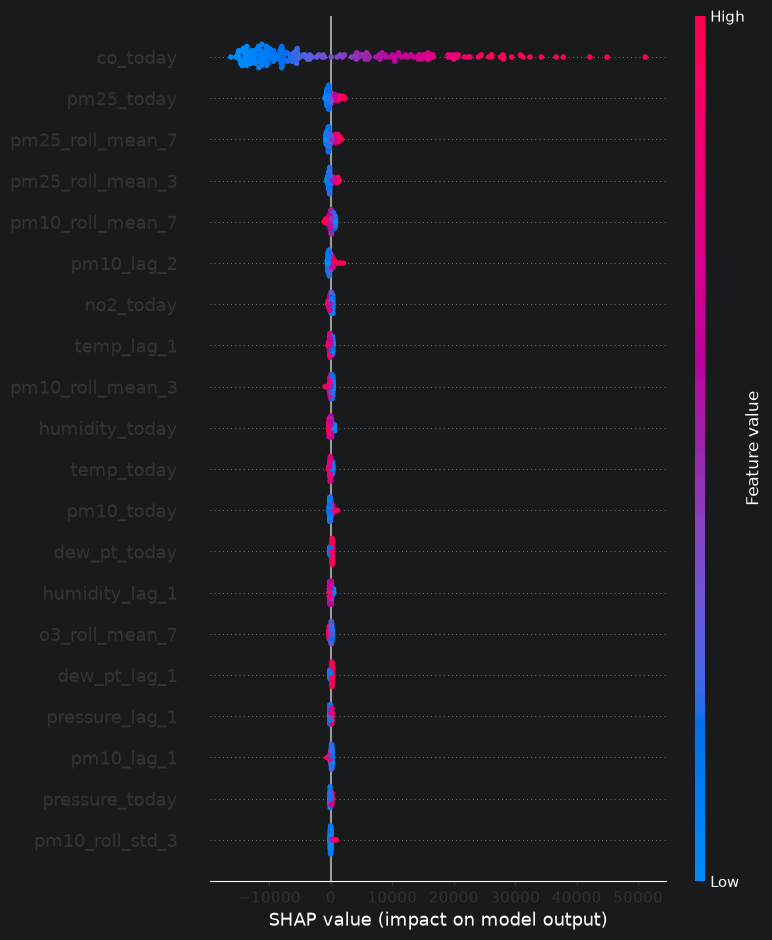

C:\Users\Lucky\AppData\Local\Temp\ipykernel_7896\4114621593.py:38: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


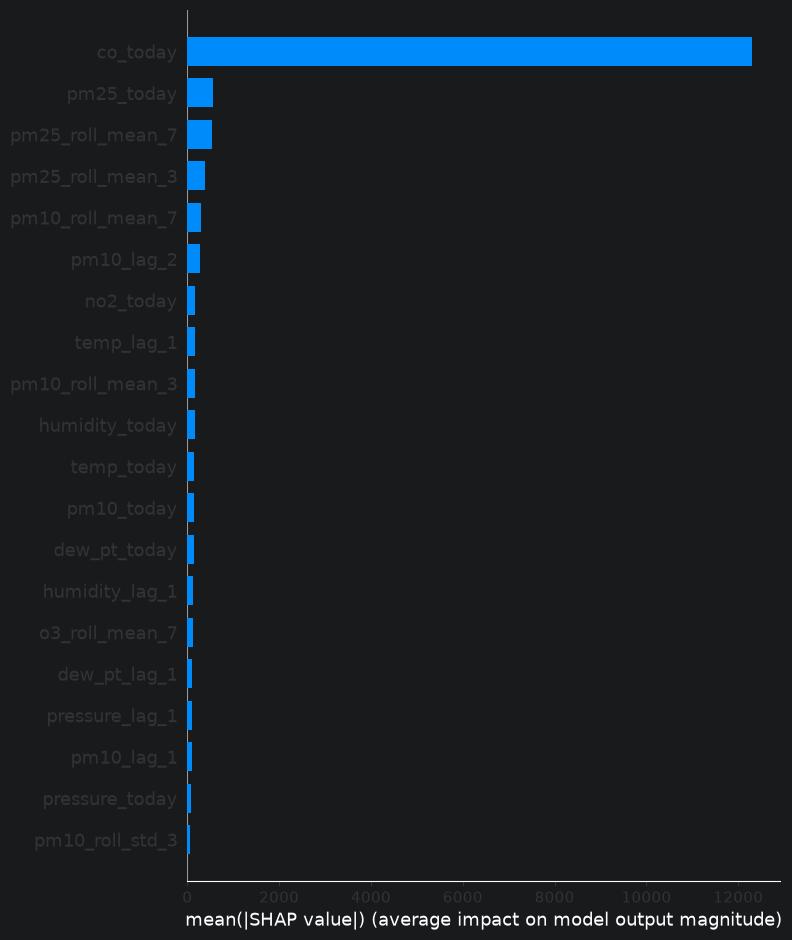

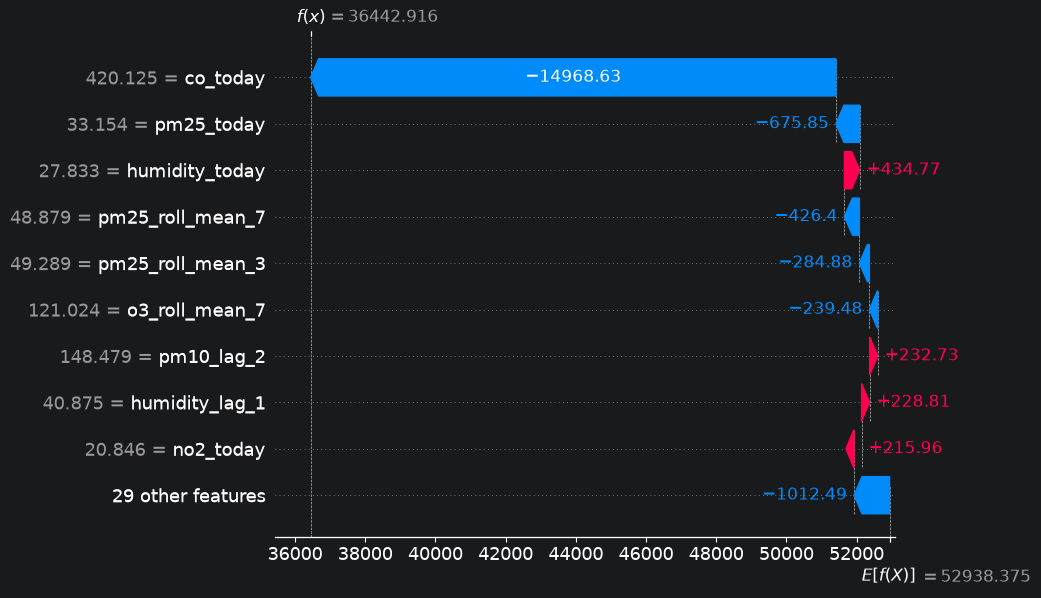

In [51]:
get_shap(xgboost_rfecv_features, mlp_model_xgboost_rfecv)